In [ ]:
import zipfile
import os

# Unzip archive.zip into a directory named 'data'
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# List extracted files to see the exact CSV filename
files = os.listdir('data')
print("Extracted files:", files)

Extracted files: ['openfoodfacts_nutrition_final_2025-12-10.csv']


In [ ]:
import pandas as pd

# Find the csv file automatically
csv_file = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join('data', csv_file)

df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (9804, 20)


,code,product_name,brands,countries,quantity,categories,labels,nutriscore_grade,ecoscore_grade,nova_group,ingredients_text,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,6111035000430,Sidi Ali,سيدي علي,Morocco,33 cl,"Beverages and beverages preparations,Beverages...",NaN,a,not-applicable,NaN,OBD1 999 999 1112606 266963207 mb,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.000000,0.000000
1,6111242100992,perly,perly,"Morocco,United States",100 g,"Dairies,Fermented foods,Fermented milk product...",NaN,unknown,b,3.0,"milk cream, cream, sugar, banana, bacteria",97.0,3.0,NaN,9.4,NaN,NaN,8.0,NaN,NaN
2,6111035002175,Sidi Ali,Sidi Ali,Morocco,2 L,"Beverages and beverages preparations,Beverages...",Green Dot,a,not-applicable,1.0,"Sodium, Calcium, Magnésium, Potassium, Bicarbo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000
3,6111035000058,Eau minérale naturelle,"Les Eaux Minérales d'oulmès,Sidi Ali",Morocco,"1,5 L","Beverages and beverages preparations,Beverages...","ISO 22000,ISO 14001,ISO 45001,ISO 9001",a,not-applicable,1.0,100% mineral water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000
4,6111252421568,اكوافينا,AQUAFINA,المغرب,33cl,"Boissons et préparations de boissons,Boissons,...",NaN,a,not-applicable,NaN,ouverture et avant le : Voir bouteille. après ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000508,0.000203


In [ ]:
!pip install python-docx seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 16.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import docx
from docx.shared import Inches, Pt, RGBColor
from google.colab import files

# Set plot style globally
sns.set_theme(style="whitegrid")

Data Cleaning & Preprocessing

In [ ]:
# Standardize column names to lowercase for easier selection
df.columns = [c.lower().strip().replace(' ', '_') for c in df.columns]

# Detect key numeric columns dynamically
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Handle missing values: fill numeric NAs with column median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Data Cleaning Complete! Processed {len(df)} rows across {len(numeric_cols)} numeric columns.")

Data Cleaning Complete! Processed 9804 rows across 11 numeric columns.


Generate EDA Visualizations

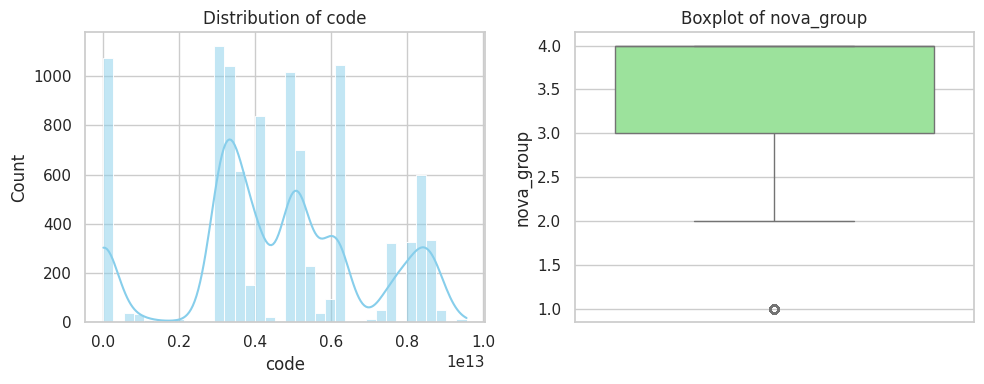

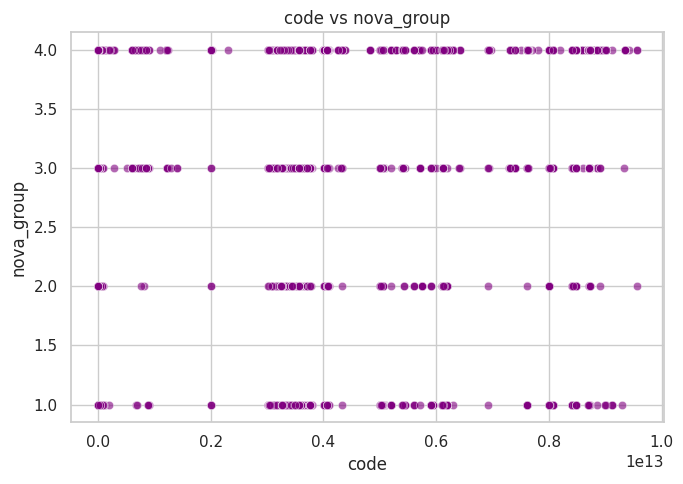

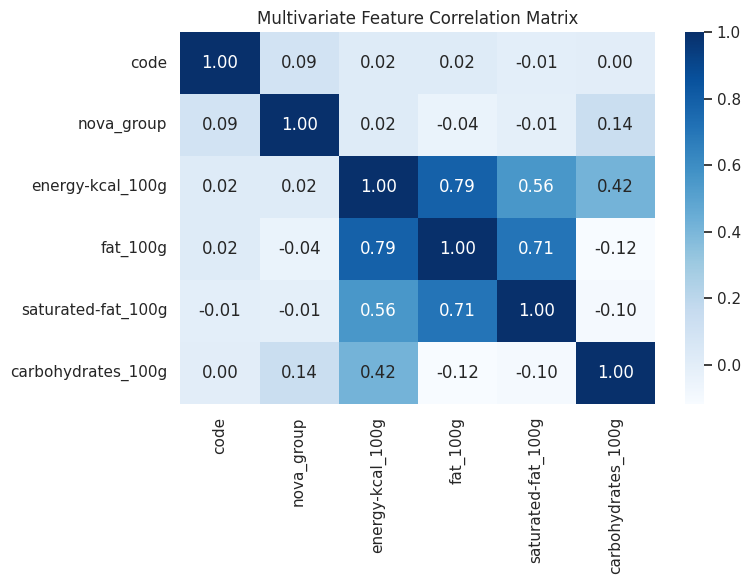

All visual plots displayed above and saved as PNG images successfully!


In [ ]:
# Plot 1: Distributions (Univariate)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
first_num = numeric_cols[0] if len(numeric_cols) > 0 else df.columns[0]
sns.histplot(df[first_num], kde=True, color='skyblue')
plt.title(f'Distribution of {first_num}')

plt.subplot(1, 2, 2)
if len(numeric_cols) > 1:
    sns.boxplot(y=df[numeric_cols[1]], color='lightgreen')
    plt.title(f'Boxplot of {numeric_cols[1]}')
plt.tight_layout()
plt.savefig('fig1_univariate.png', dpi=300)
plt.show()  # Displays image directly in Colab output

# Plot 2: Scatter Plot (Bivariate)
if len(numeric_cols) >= 2:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=numeric_cols[0], y=numeric_cols[1], alpha=0.6, color='purple')
    plt.title(f'{numeric_cols[0]} vs {numeric_cols[1]}')
    plt.tight_layout()
    plt.savefig('fig2_bivariate.png', dpi=300)
    plt.show()  # Displays image directly in Colab output

# Plot 3: Correlation Heatmap (Multivariate)
plt.figure(figsize=(8, 6))
corr = df[numeric_cols[:6]].corr() # top 6 numeric features
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Multivariate Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('fig3_correlation.png', dpi=300)
plt.show()  # Displays image directly in Colab output

print("All visual plots displayed above and saved as PNG images successfully!")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# 1. Load the dataset cleaned during EDA
#df = pd.read_csv('data/openfoodfacts_nutrition_final_2025-12-10.csv')

# ---------------------------------------------------------
# Step 1: Feature Engineering & Ratios
# ---------------------------------------------------------
# Create meaningful domain-specific nutritional metrics
df['sugar_to_carbs_ratio'] = df['sugars_100g'] / (df['carbohydrates_100g'] + 1e-5)
df['sat_fat_to_total_fat_ratio'] = df['saturated-fat_100g'] / (df['fat_100g'] + 1e-5)

# Clip ratios to a valid range [0, 1] to handle data anomalies
df['sugar_to_carbs_ratio'] = df['sugar_to_carbs_ratio'].clip(0, 1)
df['sat_fat_to_total_fat_ratio'] = df['sat_fat_to_total_fat_ratio'].clip(0, 1)


# ---------------------------------------------------------
# Step 2: Outlier Handling (IQR Capping)
# ---------------------------------------------------------
# Nutrients per 100g physically cannot exceed 100g. We cap numerical outliers.
num_cols = [
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
    'proteins_100g', 'salt_100g', 'sodium_100g'
]

# Physical constraint capping (0g to 100g limit for standard weight features)
macro_cols = ['fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g']
for col in macro_cols:
    df[col] = df[col].clip(lower=0, upper=100)

# Statistical IQR Winsorization for energy & salt metrics
for col in ['energy-kcal_100g', 'salt_100g', 'sodium_100g']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=0, upper=upper_bound)


# ---------------------------------------------------------
# Step 3: Categorical Encoding
# ---------------------------------------------------------
# Encode Nutri-Score target variable (Ordinal: A=0, B=1, C=2, D=3, E=4)
nutriscore_map = {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4}
if 'nutriscore_grade' in df.columns:
    df['nutriscore_encoded'] = df['nutriscore_grade'].str.lower().map(nutriscore_map)

# Target encode or group high-cardinality columns (e.g., top 10 categories)
if 'categories' in df.columns:
    top_categories = df['categories'].value_counts().nlargest(10).index
    df['category_grouped'] = df['categories'].apply(lambda x: x if x in top_categories else 'Other')
    df = pd.get_dummies(df, columns=['category_grouped'], drop_first=True, prefix='cat')


# ---------------------------------------------------------
# Step 4: Feature Scaling
# ---------------------------------------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled_features, columns=[f"{c}_scaled" for c in num_cols])

# Combine processed features into final DataFrame
df_processed = pd.concat([df, scaled_df], axis=1)

# Save processed output
df_processed.to_csv('openfoodfacts_processed_ml_ready.csv', index=False)
print("Processing complete. Saved 'openfoodfacts_processed_ml_ready.csv'.")

Processing complete. Saved 'openfoodfacts_processed_ml_ready.csv'.
